In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE  

from NauralNetwork import NeuralNetwork

np.random.seed(42)

print(" Library berhasil diimport!")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")


 Library berhasil diimport!
   NumPy   : 2.2.6
   Pandas  : 2.2.3


## 2.  Load Dataset

In [2]:
df = pd.read_csv('../data/raw/bank/bank-full.csv', sep=';')

print(f"Shape dataset : {df.shape}")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
df.head()


Shape dataset : (45211, 17)
Jumlah baris  : 45,211
Jumlah kolom  : 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print("=== TIPE DATA ===")
print(df.dtypes)
print("\n=== DISTRIBUSI TARGET ===")
dist = df['y'].value_counts()
print(dist)
print(f"\nRasio imbalanced: {dist['no']/dist['yes']:.1f}:1 (no:yes)")


=== TIPE DATA ===
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

=== DISTRIBUSI TARGET ===
y
no     39922
yes     5289
Name: count, dtype: int64

Rasio imbalanced: 7.5:1 (no:yes)


## 3. Exploratory Data Analysis (EDA)

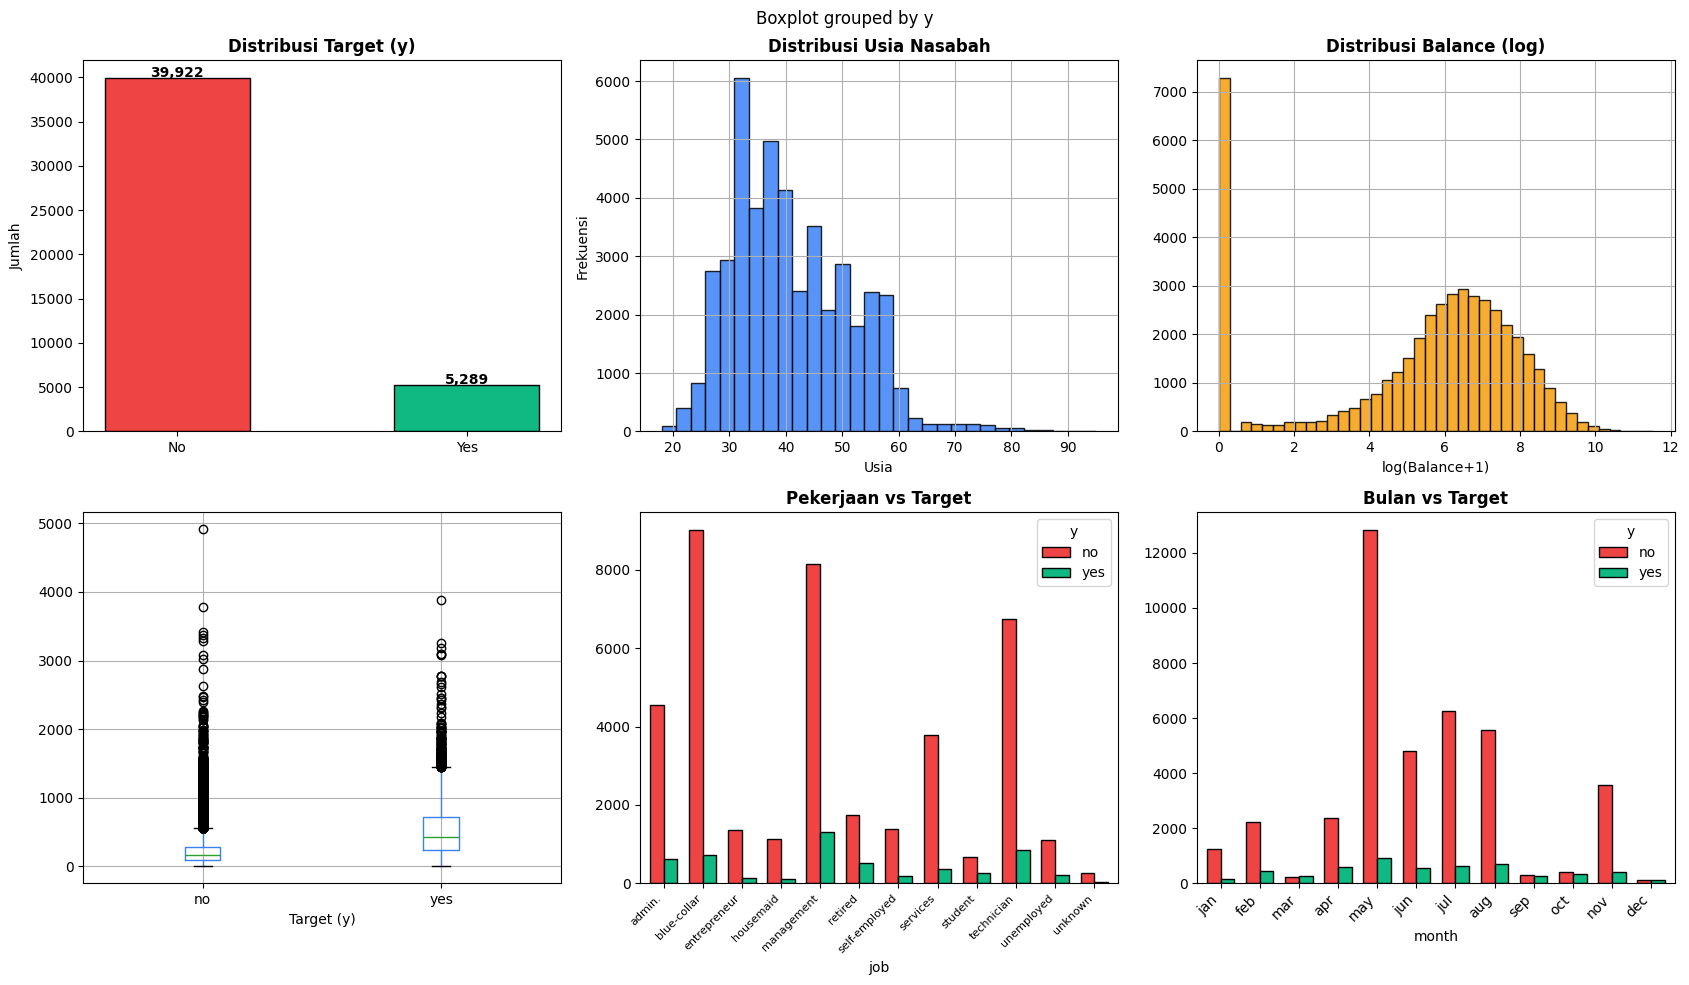

EDA selesai.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle('Exploratory Data Analysis — bank-full.csv', fontsize=14, fontweight='bold')

dist = df['y'].value_counts()

axes[0,0].bar(['No','Yes'], dist.values, color=['#ef4444','#10b981'], edgecolor='black', width=0.5)
axes[0,0].set_title('Distribusi Target (y)', fontweight='bold')
axes[0,0].set_ylabel('Jumlah')
for i, v in enumerate(dist.values):
    axes[0,0].text(i, v+100, f'{v:,}', ha='center', fontweight='bold')

df['age'].hist(ax=axes[0,1], bins=30, color='#3b82f6', edgecolor='black', alpha=0.85)
axes[0,1].set_title('Distribusi Usia Nasabah', fontweight='bold')
axes[0,1].set_xlabel('Usia'); axes[0,1].set_ylabel('Frekuensi')

df['balance'].clip(lower=0).apply(lambda x: np.log1p(x)).hist(
    ax=axes[0,2], bins=40, color='#f59e0b', edgecolor='black', alpha=0.85)
axes[0,2].set_title('Distribusi Balance (log)', fontweight='bold')
axes[0,2].set_xlabel('log(Balance+1)')

df.boxplot(column='duration', by='y', ax=axes[1,0],
           boxprops=dict(color='#3b82f6'),
           whiskerprops=dict(color='#3b82f6'))
axes[1,0].set_title('Durasi Panggilan vs Target', fontweight='bold')
axes[1,0].set_xlabel('Target (y)'); plt.sca(axes[1,0]); plt.title('')

job_target = df.groupby(['job','y']).size().unstack(fill_value=0)
job_target.plot(kind='bar', ax=axes[1,1], color=['#ef4444','#10b981'], edgecolor='black', width=0.7)
axes[1,1].set_title('Pekerjaan vs Target', fontweight='bold')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45, ha='right', fontsize=8)

month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_target = df.groupby(['month','y']).size().unstack(fill_value=0)
month_target = month_target.reindex([m for m in month_order if m in month_target.index])
month_target.plot(kind='bar', ax=axes[1,2], color=['#ef4444','#10b981'], edgecolor='black', width=0.7)
axes[1,2].set_title('Bulan vs Target', fontweight='bold')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print("EDA selesai.")


## 4. Preprocessing Data

In [5]:
num_cols = ['age','balance','day','duration','campaign','pdays','previous']
bin_cols = ['default','housing','loan']
cat_cols = ['job','marital','education','contact','month','poutcome']
target   = 'y'



df_proc = df.copy()


le = LabelEncoder()
for col in bin_cols:
    df_proc[col] = le.fit_transform(df_proc[col])

df_proc = pd.get_dummies(df_proc, columns=cat_cols, drop_first=False)

df_proc[target] = (df_proc[target] == 'yes').astype(int)

print(f"Shape setelah encoding : {df_proc.shape}")
print(f"Jumlah fitur input     : {df_proc.shape[1] - 1} neuron")


Shape setelah encoding : (45211, 49)
Jumlah fitur input     : 48 neuron


In [6]:
X = df_proc.drop(columns=[target]).values.astype(np.float64)
y = df_proc[target].values.astype(np.float64)

scaler = StandardScaler()
num_idx = [df_proc.drop(columns=[target]).columns.tolist().index(c) for c in num_cols]
X[:, num_idx] = scaler.fit_transform(X[:, num_idx])


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Jumlah fitur (neuron input) : {X.shape[1]}")
print(f"X_train : {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test : {y_test.shape}")
no_count_before = int((y_train==0).sum())
yes_count_before = int((y_train==1).sum())
print(f"\nDistribusi Kelas Training SEBELUM SMOTE:")
print(f"   Class 0 (No)  : {no_count_before:,} ({no_count_before/len(y_train)*100:.2f}%)")
print(f"   Class 1 (Yes) : {yes_count_before:,} ({yes_count_before/len(y_train)*100:.2f}%)")
print(f"   Rasio Imbalance: {no_count_before/yes_count_before:.2f}:1 (No:Yes)")


Jumlah fitur (neuron input) : 48
X_train : (36168, 48)  |  y_train: (36168,)
X_test  : (9043, 48)   |  y_test : (9043,)

Distribusi Kelas Training SEBELUM SMOTE:
   Class 0 (No)  : 31,937 (88.30%)
   Class 1 (Yes) : 4,231 (11.70%)
   Rasio Imbalance: 7.55:1 (No:Yes)


In [8]:



smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

no_count_after = int((y_train_smote==0).sum())
yes_count_after = int((y_train_smote==1).sum())
print(f"X_train_smote : {X_train_smote.shape}  |  y_train_smote: {y_train_smote.shape}")
print(f"\nDistribusi Kelas Training SETELAH SMOTE:")
print(f"   Class 0 (No)  : {no_count_after:,} ({no_count_after/len(y_train_smote)*100:.2f}%)")
print(f"   Class 1 (Yes) : {yes_count_after:,} ({yes_count_after/len(y_train_smote)*100:.2f}%)")
print(f"   Rasio Balance : {no_count_after/yes_count_after:.2f}:1 (hampir 1:1)")

X_train = X_train_smote
y_train = y_train_smote



X_train_smote : (63874, 48)  |  y_train_smote: (63874,)

Distribusi Kelas Training SETELAH SMOTE:
   Class 0 (No)  : 31,937 (50.00%)
   Class 1 (Yes) : 31,937 (50.00%)
   Rasio Balance : 1.00:1 (hampir 1:1)


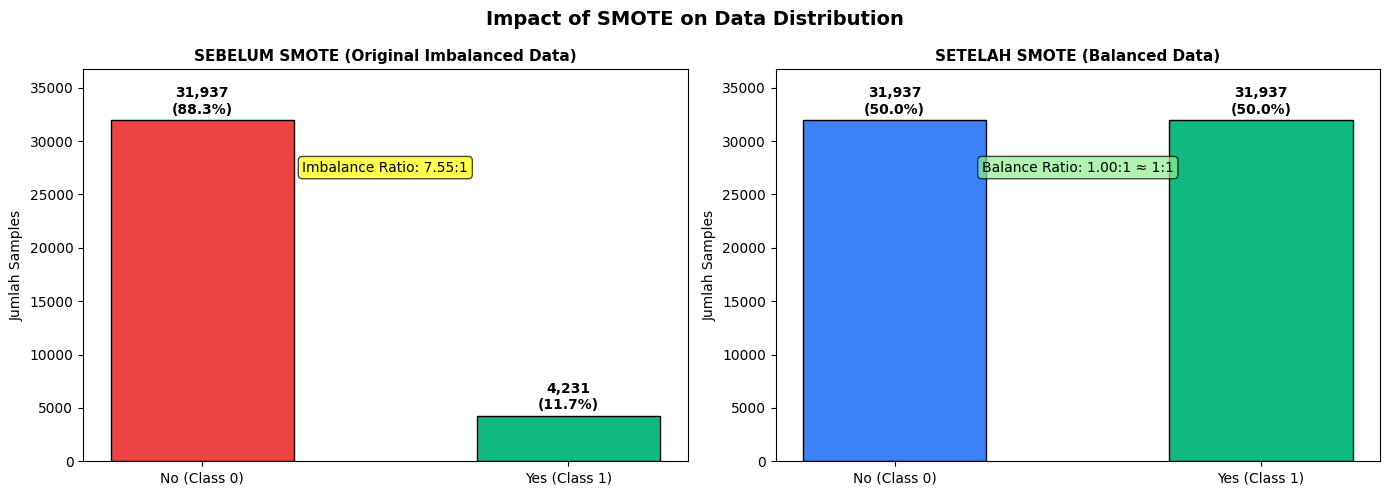

Visualisasi SMOTE tersimpan sebagai 'smote_comparison.png'


In [9]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact of SMOTE on Data Distribution', fontsize=14, fontweight='bold')

dist_before = [no_count_before, yes_count_before]
axes[0].bar(['No (Class 0)', 'Yes (Class 1)'], dist_before, color=['#ef4444', '#10b981'], edgecolor='black', width=0.5)
axes[0].set_title('SEBELUM SMOTE (Original Imbalanced Data)', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Jumlah Samples')
axes[0].set_ylim(0, max(dist_before) * 1.15)
for i, v in enumerate(dist_before):
    axes[0].text(i, v + max(dist_before)*0.02, f'{v:,}\n({v/sum(dist_before)*100:.1f}%)', 
                ha='center', fontweight='bold', fontsize=10)
axes[0].text(0.5, max(dist_before)*0.85, f'Imbalance Ratio: {no_count_before/yes_count_before:.2f}:1', 
            ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7), transform=axes[0].transData)


dist_after = [no_count_after, yes_count_after]
axes[1].bar(['No (Class 0)', 'Yes (Class 1)'], dist_after, color=['#3b82f6', '#10b981'], edgecolor='black', width=0.5)
axes[1].set_title('SETELAH SMOTE (Balanced Data)', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Jumlah Samples')
axes[1].set_ylim(0, max(dist_after) * 1.15)
for i, v in enumerate(dist_after):
    axes[1].text(i, v + max(dist_after)*0.02, f'{v:,}\n({v/sum(dist_after)*100:.1f}%)', 
                ha='center', fontweight='bold', fontsize=10)
axes[1].text(0.5, max(dist_after)*0.85, f'Balance Ratio: {no_count_after/yes_count_after:.2f}:1 ≈ 1:1', 
            ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7), transform=axes[1].transData)

plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Visualisasi SMOTE tersimpan sebagai 'smote_comparison.png'")


## 5. Visualisasi Arsitektur Neural Network

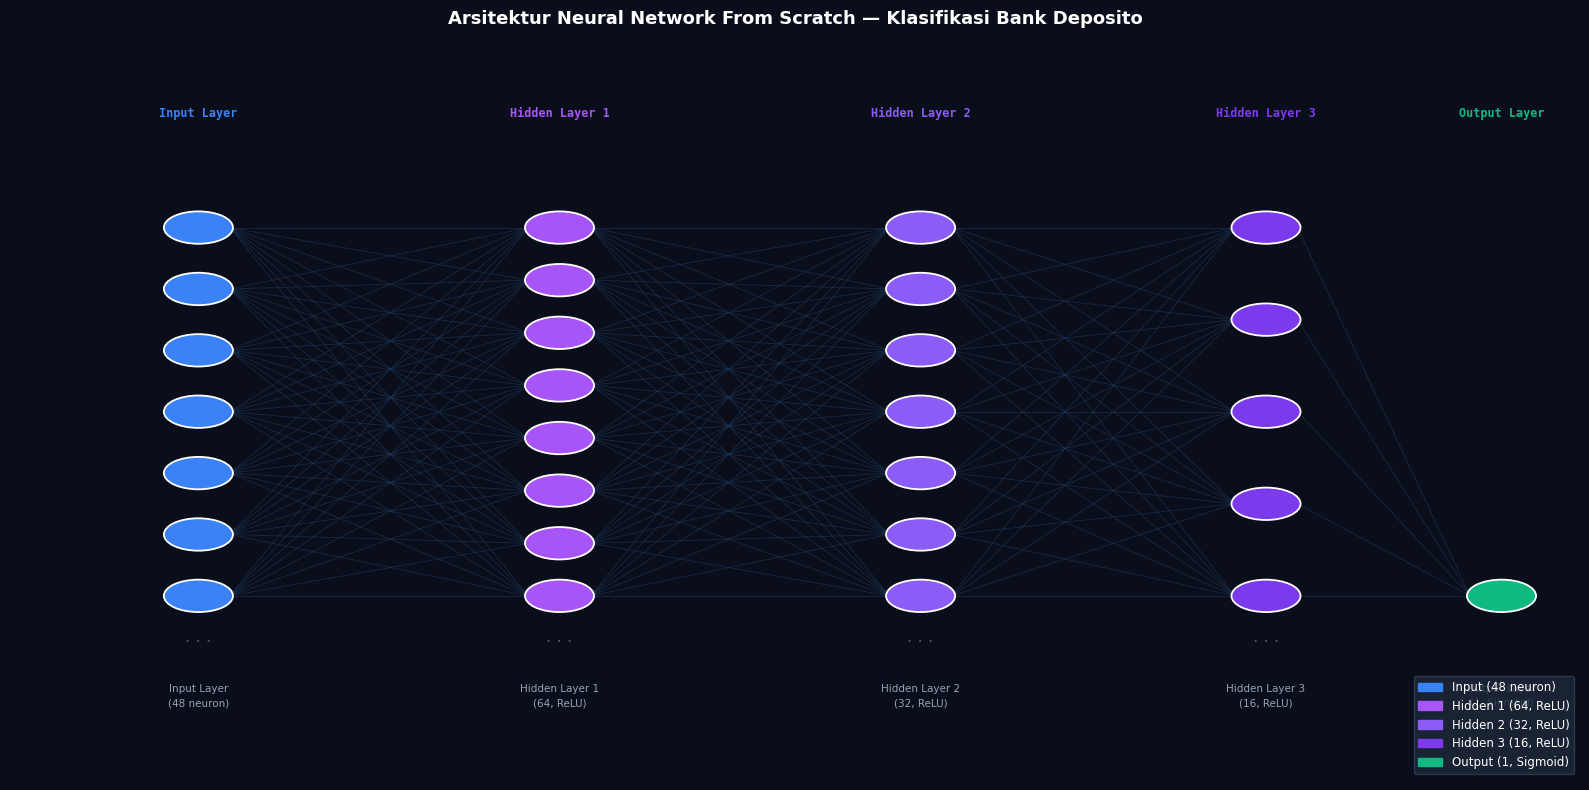

Diagram arsitektur tersimpan.


In [10]:
def draw_architecture(input_dim):
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
    ax.set_facecolor('#0a0e1a'); fig.patch.set_facecolor('#0a0e1a')

    layers_cfg = [
        {'label': f'Input Layer\n({input_dim} neuron)', 'n': 7, 'x': 1.2,  'color': '#3b82f6'},
        {'label': 'Hidden Layer 1\n(64, ReLU)',          'n': 8, 'x': 3.5,  'color': '#a855f7'},
        {'label': 'Hidden Layer 2\n(32, ReLU)',          'n': 7, 'x': 5.8,  'color': '#8b5cf6'},
        {'label': 'Hidden Layer 3\n(16, ReLU)',          'n': 5, 'x': 8.0,  'color': '#7c3aed'},
        {'label': 'Output Layer\n(1, Sigmoid)',          'n': 1, 'x': 9.5,  'color': '#10b981'},
    ]

    positions = []
    for cfg in layers_cfg:
        ys = np.linspace(2.5, 7.5, cfg['n'])
        positions.append((cfg['x'], ys))

    for i in range(len(positions)-1):
        x1, ys1 = positions[i]; x2, ys2 = positions[i+1]
        for y1 in ys1:
            for y2 in ys2:
                ax.plot([x1+0.2, x2-0.2], [y1, y2], color='#1e3a5f', lw=0.6, alpha=0.6)

    for idx, cfg in enumerate(layers_cfg):
        x, ys = positions[idx]
        for y in ys:
            ax.add_patch(plt.Circle((x, y), 0.22, color=cfg['color'], ec='white', lw=1.3, zorder=3))
        ax.text(x, 9.0, cfg['label'].split('\n')[0],
                ha='center', color=cfg['color'], fontsize=8.5, fontweight='bold', fontfamily='monospace')
        ax.text(x, 1.0, cfg['label'], ha='center', color='#94a3b8', fontsize=7.5, linespacing=1.5)
        if idx < 4:
            ax.text(x, 1.8, '· · ·', ha='center', color='#475569', fontsize=12)

    ax.set_title('Arsitektur Neural Network From Scratch — Klasifikasi Bank Deposito',
                 color='white', fontsize=13, fontweight='bold', pad=14)

    legend = [
        mpatches.Patch(color='#3b82f6', label=f'Input ({input_dim} neuron)'),
        mpatches.Patch(color='#a855f7', label='Hidden 1 (64, ReLU)'),
        mpatches.Patch(color='#8b5cf6', label='Hidden 2 (32, ReLU)'),
        mpatches.Patch(color='#7c3aed', label='Hidden 3 (16, ReLU)'),
        mpatches.Patch(color='#10b981', label='Output (1, Sigmoid)'),
    ]
    ax.legend(handles=legend, loc='lower right', facecolor='#1e293b',
              edgecolor='#334155', labelcolor='white', fontsize=8.5)

    plt.tight_layout()
    plt.savefig('nn_architecture.png', dpi=130, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show()
    print("Diagram arsitektur tersimpan.")

draw_architecture(X_train.shape[1])


## 7. Jalankan Training

In [11]:
input_dim   = X_train.shape[1]
layer_dims  = [input_dim, 64, 32, 16, 1]

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print(f"Split untuk validation:")
print(f"   X_tr  : {X_tr.shape} (training)")
print(f"   X_val : {X_val.shape} (validation)")
print(f"   X_test: {X_test.shape} (test - original, tidak dimodifikasi)")
print()
print("Training dimulai...\n")

nn = NeuralNetwork(layer_dims=layer_dims, random_seed=42)
history = nn.train(
    X_tr, y_tr, X_val, y_val,
    epochs=100,
    batch_size=64,
    lr=0.001,
    patience=10,
    verbose=True
)


best_params = nn.params


Split untuk validation:
   X_tr  : (54292, 48) (training)
   X_val : (9582, 48) (validation)
   X_test: (9043, 48) (test - original, tidak dimodifikasi)

Training dimulai...



Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

Epoch   1/100 | Train Loss: 0.2959 | Val Loss: 0.3012 | Val Acc: 0.8742 | Val AUC: 0.0607
Epoch  10/100 | Train Loss: 0.1808 | Val Loss: 0.2157 | Val Acc: 0.9211 | Val AUC: 0.0353
Epoch  20/100 | Train Loss: 0.1396 | Val Loss: 0.1948 | Val Acc: 0.9326 | Val AUC: 0.0306
Epoch  30/100 | Train Loss: 0.1207 | Val Loss: 0.1944 | Val Acc: 0.9348 | Val AUC: 0.0296
Epoch  40/100 | Train Loss: 0.1040 | Val Loss: 0.1893 | Val Acc: 0.9365 | Val AUC: 0.0272
Epoch  50/100 | Train Loss: 0.0962 | Val Loss: 0.2025 | Val Acc: 0.9387 | Val AUC: 0.0289

⏹Early stopping pada epoch 50 (val_loss tidak membaik selama 10 epoch)


## 8. Learning Curves

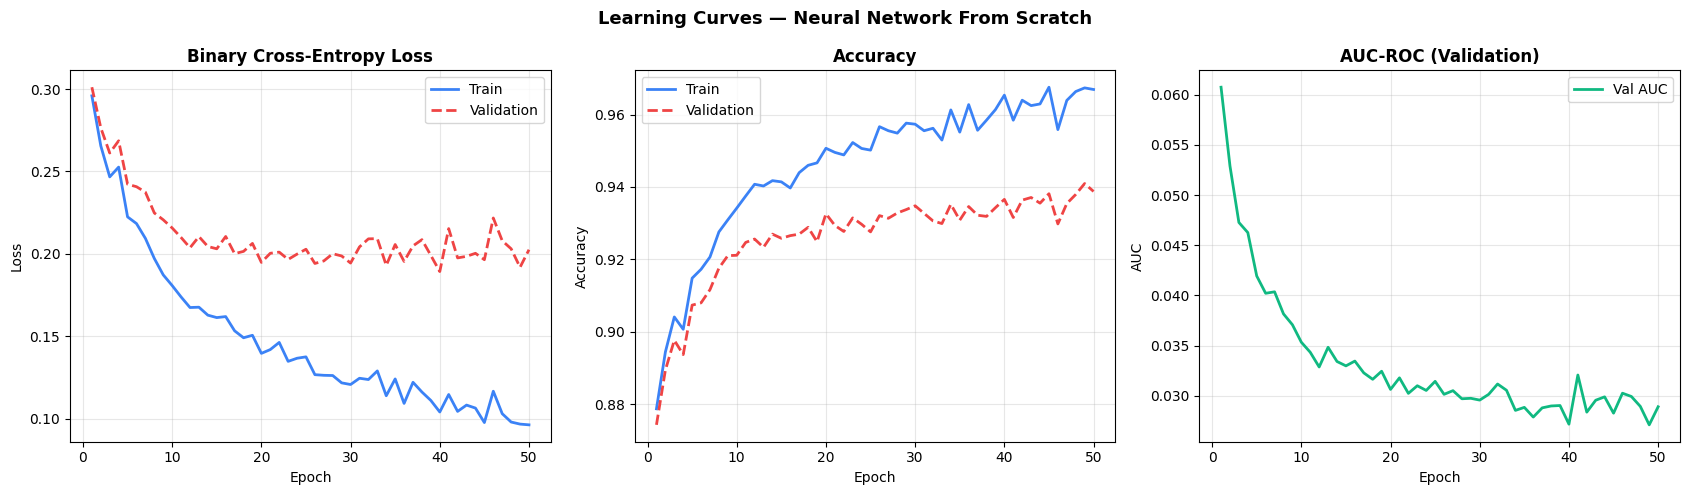

Learning curves selesai.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Learning Curves — Neural Network From Scratch', fontsize=13, fontweight='bold')

epochs_ran = list(range(1, len(history['train_loss'])+1))

# Loss
axes[0].plot(epochs_ran, history['train_loss'], '#3b82f6', lw=2, label='Train')
axes[0].plot(epochs_ran, history['val_loss'],   '#ef4444', lw=2, ls='--', label='Validation')
axes[0].set_title('Binary Cross-Entropy Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history['train_acc'], '#3b82f6', lw=2, label='Train')
axes[1].plot(epochs_ran, history['val_acc'],   '#ef4444', lw=2, ls='--', label='Validation')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(epochs_ran, history['val_auc'], '#10b981', lw=2, label='Val AUC')
axes[2].set_title('AUC-ROC (Validation)', fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('AUC')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print("Learning curves selesai.")


## 9. 📊 Evaluasi Model pada Test Set

In [13]:
y_prob = nn.predict(X_test)
y_pred = (y_prob >= 0.5).astype(int)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_recall_f1(y_true, y_pred):
    TP = ((y_pred==1) & (y_true==1)).sum()
    FP = ((y_pred==1) & (y_true==0)).sum()
    FN = ((y_pred==0) & (y_true==1)).sum()
    TN = ((y_pred==0) & (y_true==0)).sum()
    prec = TP / (TP + FP + 1e-8)
    rec  = TP / (TP + FN + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    spec = TN / (TN + FP + 1e-8)
    return prec, rec, f1, spec, TP, FP, FN, TN

acc                             = accuracy(y_test, y_pred)
prec, rec, f1, spec, TP,FP,FN,TN = precision_recall_f1(y_test, y_pred)
auc                             = roc_auc_score(y_test, y_prob)
loss                            = NeuralNetwork.binary_cross_entropy(y_test, y_prob)

print("=" * 50)
print("     HASIL EVALUASI — TEST SET")
print("=" * 50)
print(f"  Accuracy    : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision   : {prec:.4f}")
print(f"  Recall      : {rec:.4f}")
print(f"  Specificity : {spec:.4f}")
print(f"  F1-Score    : {f1:.4f}")
print(f"  AUC-ROC     : {auc:.4f}")
print(f"  BCE Loss    : {loss:.4f}")
print("=" * 50)
print(f"\n  TP={int(TP):,}  FP={int(FP):,}  FN={int(FN):,}  TN={int(TN):,}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No (0)','Yes (1)']))


     HASIL EVALUASI — TEST SET
  Accuracy    : 0.8811  (88.11%)
  Precision   : 0.4936
  Recall      : 0.6191
  Specificity : 0.9158
  F1-Score    : 0.5493
  AUC-ROC     : 0.8967
  BCE Loss    : 0.4517

  TP=655  FP=672  FN=403  TN=7,313

=== Classification Report ===
              precision    recall  f1-score   support

      No (0)       0.95      0.92      0.93      7985
     Yes (1)       0.49      0.62      0.55      1058

    accuracy                           0.88      9043
   macro avg       0.72      0.77      0.74      9043
weighted avg       0.89      0.88      0.89      9043



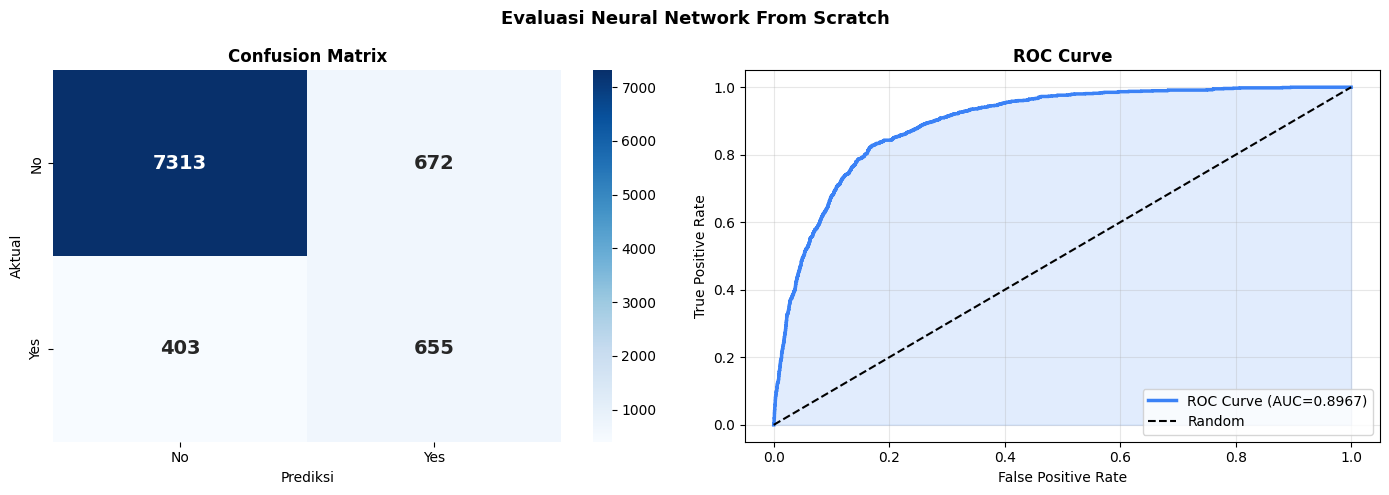

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Evaluasi Neural Network From Scratch', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No','Yes'], yticklabels=['No','Yes'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, '#3b82f6', lw=2.5, label=f'ROC Curve (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#3b82f6')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=120, bbox_inches='tight')
plt.show()


## 10. Visualisasi Bobot Neural Network

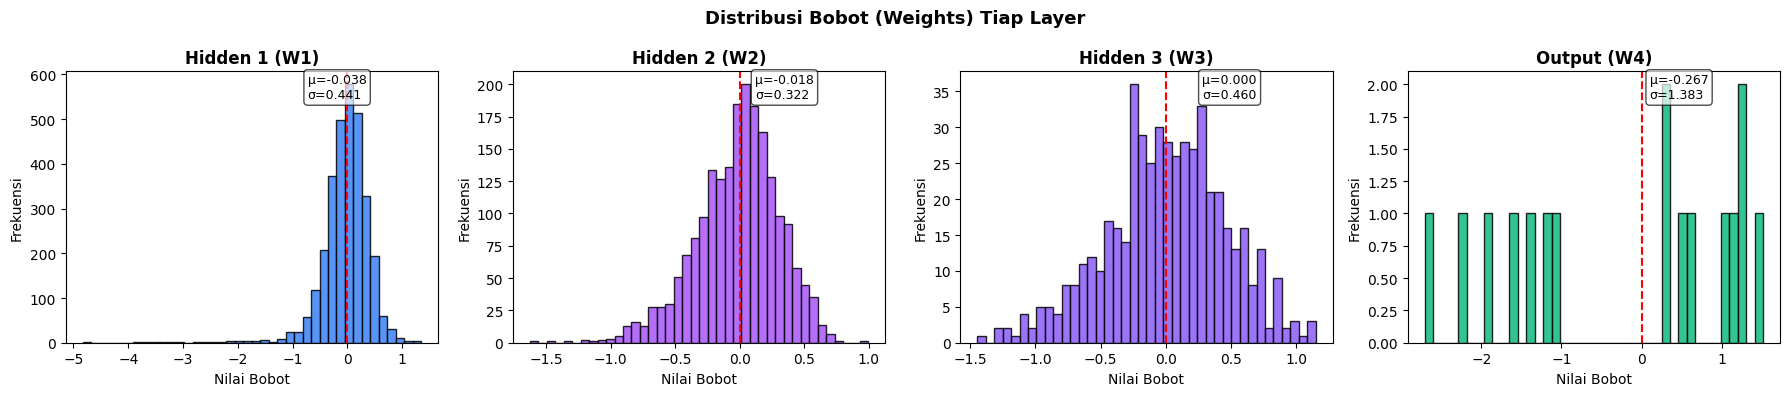

 Distribusi bobot divisualisasikan.


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribusi Bobot (Weights) Tiap Layer', fontsize=13, fontweight='bold')

layer_names = ['Hidden 1 (W1)', 'Hidden 2 (W2)', 'Hidden 3 (W3)', 'Output (W4)']
colors = ['#3b82f6', '#a855f7', '#8b5cf6', '#10b981']
params_source = best_params if 'best_params' in globals() else nn.params

for i, (name, color) in enumerate(zip(layer_names, colors), start=1):
    W = params_source[f'W{i}'].flatten()
    axes[i-1].hist(W, bins=40, color=color, edgecolor='black', alpha=0.85)
    axes[i-1].set_title(name, fontweight='bold')
    axes[i-1].set_xlabel('Nilai Bobot')
    axes[i-1].set_ylabel('Frekuensi')
    axes[i-1].axvline(0, color='red', ls='--', lw=1.5, label='W=0')
    axes[i-1].text(0.65, 0.9, f'μ={W.mean():.3f}\nσ={W.std():.3f}',
                   transform=axes[i-1].transAxes, fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('weights_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Distribusi bobot divisualisasikan.")


## 11. Demo Prediksi Nasabah Baru

In [16]:
sample_idx  = np.random.choice(len(X_test), 8, replace=False)
X_sample    = X_test[sample_idx]
y_sample    = y_test[sample_idx]
prob_sample = nn.predict(X_sample)
pred_sample = (prob_sample >= 0.5).astype(int)

print("=" * 65)
print("  DEMO PREDIKSI NASABAH BARU")
print("=" * 65)
print(f"{'No':>3} | {'Aktual':>8} | {'Prediksi':>10} | {'Probabilitas':>14} | {'Status':>8}")
print("-" * 65)
for i in range(len(sample_idx)):
    aktual   = 'Yes' if y_sample[i] == 1 else 'No'
    prediksi = 'Yes' if pred_sample[i] == 1 else 'No'
    prob     = prob_sample[i]
    status   = ' Benar' if y_sample[i] == pred_sample[i] else ' Salah'
    print(f"  {i+1} | {aktual:>8} | {prediksi:>10} | {prob:>13.2%} | {status}")
print("=" * 65)


  DEMO PREDIKSI NASABAH BARU
 No |   Aktual |   Prediksi |   Probabilitas |   Status
-----------------------------------------------------------------
  1 |       No |         No |         0.00% |  Benar
  2 |       No |         No |         0.00% |  Benar
  3 |       No |         No |         0.00% |  Benar
  4 |       No |         No |         0.00% |  Benar
  5 |       No |         No |         0.01% |  Benar
  6 |       No |         No |         0.00% |  Benar
  7 |       No |         No |         0.00% |  Benar
  8 |       No |         No |         0.01% |  Benar
